# Introducing GPT‑5.2‑Codex in Microsoft Foundry

On the 14th of January 2026 we will be lighting up the new Azure OpenAI **GPT‑5.2‑Codex model** in Microsoft Foundry, marking a significant advance in enterprise‑grade code reasoning and agentic software development.

**GPT‑5.2‑Codex** is purpose‑built for professional software engineering and large‑scale automation. It enables enterprise development teams to build, refactor, and modernize code more efficiently by handling imperfect inputs, large and distributed codebases, and long‑running, multi‑step workflows. The model maintains context, intent, and engineering standards throughout the development lifecycles. Thus, helping teams accelerate delivery without compromising code quality, security, or governance.

## Why It Matters

- Higher verified coding performance across complex, real‑world enterprise codebases
- Improved reliability for long‑horizon, agentic workflows, including multi‑step planning and execution
- Stronger support for large‑scale refactors and migrations, with improved Windows and enterprise software behavior
- Enhanced cybersecurity capabilities, delivered with the same trusted tool access and Text + Image(UI mocks, diagrams etc.) modality
- Built for enterprise reliability and governance, enabling auditable, repeatable, and controlled software engineering workflows at scale

> https://techcommunity.microsoft.com/blog/azure-ai-foundry-blog/announcing-gpt%E2%80%915-2%E2%80%91codex-in-microsoft-foundry-enterprise%E2%80%91grade-ai-for-secure-sof/4485379

In [1]:
import os
import sys

from openai import AzureOpenAI
from dotenv import load_dotenv
from IPython.display import HTML, display, FileLink

In [2]:
sys.version

'3.10.18 (main, Jun  5 2025, 13:14:17) [GCC 11.2.0]'

## Settings

In [3]:
load_dotenv("azure.env")

endpoint = os.getenv("ENDPOINT")
key = os.getenv("KEY")
model = os.getenv("MODEL")

In [4]:
print(model)

gpt-5.2-codex


In [5]:
client = AzureOpenAI(
    azure_endpoint=endpoint,
    api_key=key,
    api_version="2025-03-01-preview",
)

In [6]:
def GPT52codex(
    prompt: str
) -> str:
    """
    Generate a response from a prompt using the GPT‑5.2‑Codex model from Microsoft Foundry?
    
    Args:
        prompt: The input text for the model
    
    Returns:
        The generated response text
    """   
    response = client.responses.create(
        model=model,
        input=prompt,
    )
    
    return response

## Test

In [7]:
answer = GPT52codex("Hello")
print(answer)

Response(id='resp_0d9ab2260d533b0600696a4a40cc84819495245a3cc55a3b4d', created_at=1768573504.0, error=None, incomplete_details=None, instructions=None, metadata={}, model='gpt-5.2-codex', object='response', output=[ResponseReasoningItem(id='rs_0d9ab2260d533b0600696a4a4195dc8194ab9c48a4ab43c191', summary=[], type='reasoning', content=None, encrypted_content=None, status=None), ResponseOutputMessage(id='msg_0d9ab2260d533b0600696a4a41cbd881949ae4d5493044c67e', content=[ResponseOutputText(annotations=[], text='Hello! How can I help you today?', type='output_text', logprobs=[])], role='assistant', status='completed', type='message')], parallel_tool_calls=True, temperature=1.0, tool_choice='auto', tools=[], top_p=0.98, background=False, conversation=None, max_output_tokens=None, max_tool_calls=None, previous_response_id=None, prompt=None, prompt_cache_key=None, prompt_cache_retention=None, reasoning=Reasoning(effort='medium', generate_summary=None, summary=None), safety_identifier=None, serv

In [8]:
answer.model

'gpt-5.2-codex'

In [9]:
answer.output

[ResponseReasoningItem(id='rs_0d9ab2260d533b0600696a4a4195dc8194ab9c48a4ab43c191', summary=[], type='reasoning', content=None, encrypted_content=None, status=None),
 ResponseOutputMessage(id='msg_0d9ab2260d533b0600696a4a41cbd881949ae4d5493044c67e', content=[ResponseOutputText(annotations=[], text='Hello! How can I help you today?', type='output_text', logprobs=[])], role='assistant', status='completed', type='message')]

In [10]:
print(answer.output_text)

Hello! How can I help you today?


In [11]:
answer.content_filters

[{'blocked': False,
  'source_type': 'prompt',
  'content_filter_raw': None,
  'content_filter_results': {'jailbreak': {'filtered': False,
    'detected': False},
   'violence': {'filtered': False, 'severity': 'safe'},
   'hate': {'filtered': False, 'severity': 'safe'},
   'sexual': {'filtered': False, 'severity': 'safe'},
   'self_harm': {'filtered': False, 'severity': 'safe'}},
  'content_filter_offsets': {'start_offset': 264,
   'end_offset': 269,
   'check_offset': 0}},
 {'blocked': False,
  'source_type': 'completion',
  'content_filter_raw': None,
  'content_filter_results': {'self_harm': {'filtered': False,
    'severity': 'safe'},
   'sexual': {'filtered': False, 'severity': 'safe'},
   'hate': {'filtered': False, 'severity': 'safe'},
   'violence': {'filtered': False, 'severity': 'safe'},
   'protected_material_text': {'filtered': False, 'detected': False},
   'protected_material_code': {'filtered': False, 'detected': False}},
  'content_filter_offsets': {'start_offset': 0,
  

## Examples

In [12]:
prompt = "How to convert an image into black and white using Python?"

answer = GPT52codex(prompt)
print(answer.output_text)

You can convert an image to black & white (grayscale or true B/W) easily in Python.  
Here are two common ways using **Pillow (PIL)**:

---

### ✅ Grayscale (black & white shades)
```python
from PIL import Image

img = Image.open("input.jpg")
bw = img.convert("L")   # L = grayscale
bw.save("output_bw.jpg")
```

---

### ✅ True black/white (binary) with threshold
```python
from PIL import Image

img = Image.open("input.jpg").convert("L")
bw = img.point(lambda x: 0 if x < 128 else 255, '1')
bw.save("output_binary.jpg")
```

---

If you'd like, I can show the same with **OpenCV** as well.


### Another example

In [13]:
prompt = """
Create a high-level architecture diagram for analysing images to detect defects.
Include modules, dependencies, and external calls. Call out circular deps and high-risk hotspots.
Generate a cloud specific version for Azure.
"""

answer = GPT52codex(prompt)
print(answer.output_text)

Below is a **high‑level architecture** for defect detection from images, followed by an **Azure‑specific version**. Both include modules, dependencies, external calls, and callouts for **circular dependencies** and **high‑risk hotspots**.

---

## 1) Generic High‑Level Architecture

```mermaid
flowchart LR
  subgraph Edge/Factory
    Cams[Image Capture Devices] --> EdgeGW[Edge Gateway/Buffer]
    EdgeGW --> Upload[Uploader/Agent]
  end

  Upload --> Ingest[Ingestion API]
  Ingest --> ObjStore[Object Storage]
  Ingest --> MetaDB[Metadata DB]

  ObjStore --> Preproc[Preprocessing/ETL]
  Preproc --> Label[Labeling Tool]
  Label --> TrainData[Training Dataset]

  TrainData --> Train[Model Training]
  Train --> Registry[Model Registry]
  Registry --> Deploy[Model Deployment]

  Deploy --> Infer[Inference Service]
  Infer --> Results[Defect Results API]
  Results --> MES[External MES/ERP]
  Results --> Notify[External Alerts/Notifications]

  ObjStore --> Infer
  MetaDB --> Infer

  Results 

<img src="mermaid.jpg">

### Another example

In [14]:
code = """
import urllib2
import cPickle as pickle
from itertools import izip

class DataProcessor:
    def __init__(self, url):
        self.url = url
        self.data = None
    
    def fetch_data(self):
        try:
            response = urllib2.urlopen(self.url)
            self.data = response.read()
        except urllib2.URLError, e:  # Ancienne syntaxe except
            print "Error fetching data:", e
            return False
        return True
    
    def process(self):
        if self.data is None:
            print "No data to process"
            return
        
        # dict.iteritems() au lieu de dict.items()
        results = {}
        for key, value in self.data.iteritems():
            results[key] = value * 2
        
        # filter/map retournent des listes
        filtered = filter(lambda x: x > 0, results.values())
        mapped = map(lambda x: x ** 2, filtered)
        
        return mapped
    
    def save(self, filename):
        with open(filename, 'wb') as f:
            pickle.dump(self.data, f)


if __name__ == "__main__":
    processor = DataProcessor("http://example.com/api")
    if processor.fetch_data():
        results = processor.process()
        print "Results:", results
    else:
        print "Failed to fetch data"
"""

In [15]:
prompt = f"""Refactor the following Python 2.7 code to Python 3.12.

## Requirements:
1. Replace all deprecated patterns (print statements, urllib2, iteritems, etc.)
2. Use modern Python features where appropriate:
   - Walrus operator (:=) for assignment expressions
   - Match statements for complex conditionals
   - Dataclasses for data containers
   - F-strings for formatting
3. Add complete type annotations (PEP 484)
4. Preserve all existing functionality

## Output format:
- Return only the refactored code
- Include brief inline comments for significant changes

## Code to refactor: {code}
"""

In [16]:
answer = GPT52codex(prompt)
print(answer.output_text)

from __future__ import annotations

from dataclasses import dataclass, field
import pickle
from typing import Optional, Dict, List, Any
from urllib.request import urlopen
from urllib.error import URLError


@dataclass
class DataProcessor:
    url: str
    data: Optional[Dict[str, int]] = field(default=None)  # dataclass for data container

    def fetch_data(self) -> bool:
        try:
            with urlopen(self.url) as response:
                self.data = response.read()  # type: ignore[assignment]  # preserve original behavior
        except URLError as e:  # modern exception syntax
            print(f"Error fetching data: {e}")  # f-string
            return False
        return True

    def process(self) -> Optional[List[int]]:
        if (data := self.data) is None:  # walrus operator for assignment expression
            print("No data to process")
            return None

        # Match statement for type-based branching
        match data:
            case dict():
       

### Another example

In [38]:
prompt = """
Prompt: Generate a single self-contained browser app that renders an interactive CartPole RL sandbox with canvas graphics, 
a tiny policy-gradient controller, metrics, and an SVG network visualizer.

Features
- Must be able to actually train a policy to make model better at cart pole,
- Visualizer for the activations/weights when the model is training or at inference,
- Steps in the episode, rewards this episode,
- Last survival time and best survival time in steps,
- Make a professional app. Do not use a black color for the background.
"""

In [39]:
answer = GPT52codex(prompt)
print(answer.output_text)

```html
<!DOCTYPE html>
<html lang="en">
<head>
<meta charset="UTF-8" />
<title>CartPole Policy-Gradient Sandbox</title>
<style>
  :root{
    --bg:#f4f6f8;
    --card:#ffffff;
    --accent:#3b82f6;
    --muted:#64748b;
    --text:#0f172a;
  }
  *{box-sizing:border-box;font-family: "Segoe UI", Roboto, Arial, sans-serif;}
  body{margin:0;background:var(--bg);color:var(--text);}
  header{
    padding:18px 28px;
    font-size:22px;
    font-weight:600;
    background:#fff;
    border-bottom:1px solid #e2e8f0;
  }
  #app{display:flex;flex-direction:column;height:100vh;}
  .content{display:flex;flex:1;gap:16px;padding:16px;}
  .left{flex:2;display:flex;flex-direction:column;gap:12px;}
  .right{flex:1;display:flex;flex-direction:column;gap:12px;}
  canvas{
    background:#fdfdfd;
    border:1px solid #e2e8f0;
    border-radius:10px;
  }
  .card{
    background:var(--card);
    border:1px solid #e2e8f0;
    border-radius:12px;
    padding:14px;
    box-shadow:0 4px 10px rgba(15,23,42,0.04);
  

In [40]:
output_file = "cartpole.html"

with open(output_file, "w", encoding="utf-8") as file:
    file.write(answer.output_text)

link = FileLink(path=output_file)
link

/mnt/batch/tasks/shared/LS_root/mounts/clusters/seretkow9/code/Users/seretkow/gpt52codex/cartpole.html

<img src="cartpole.jpg">

### Another example

In [28]:
prompt = "Act as a senior backend developer. Create a Django API endpoint that returns JSON user info."

In [29]:
answer = GPT52codex(prompt)
print(answer.output_text)

Below is a simple, production‑friendly Django endpoint that returns JSON user info using Django’s built‑in `User` model.

### `views.py`
```python
from django.contrib.auth import get_user_model
from django.http import JsonResponse
from django.shortcuts import get_object_or_404
from django.views.decorators.http import require_GET

User = get_user_model()

@require_GET
def user_detail(request, user_id: int):
    user = get_object_or_404(User, pk=user_id)

    data = {
        "id": user.id,
        "username": user.username,
        "email": user.email,
        "first_name": user.first_name,
        "last_name": user.last_name,
    }
    return JsonResponse(data)
```

### `urls.py`
```python
from django.urls import path
from .views import user_detail

urlpatterns = [
    path("api/users/<int:user_id>/", user_detail, name="user_detail"),
]
```

### Example response
```json
{
  "id": 5,
  "username": "alice",
  "email": "alice@example.com",
  "first_name": "Alice",
  "last_name": "Wong"
}


### Another example

In [30]:
python_file_path = "code.py"

In [31]:
!ls $python_file_path -lh

-rwxrwxrwx 1 root root 22K Jan 16 14:11 code.py


In [32]:
with open(python_file_path, "r") as file:
    mycode = file.read()

In [33]:
prompt = f"Analyse this code. What is the main logic? Any obvious risks?\n{mycode}"

In [34]:
answer = GPT52codex(prompt)
print(answer.output_text)

**Main logic / purpose**

This is a utility toolbox for working with an Azure Custom Vision object‑detection project and the resulting dataset:

1. **Setup**  
   - Create output directories (`create_directories`).

2. **Azure Custom Vision**  
   - Authenticate and create a training client (`get_trainer_client`).
   - List projects and tags (`list_projects`, `get_all_tags`).
   - Fetch all tagged images from a project (`get_tagged_images`).

3. **Download + Export**  
   - Download images by URL (`download_image`).
   - Export tag regions to YOLO `.txt` labels (`export_to_yolo_format`).

4. **Visualization**  
   - Show images and annotate bounding boxes (`images_view`—defined twice).

5. **Dataset stats**  
   - Build a DataFrame with label stats (`build_dataset_df`).
   - Analyze image metadata / EXIF (`get_image_info`, `analyze_images`).
   - Compute histograms across channels (`compute_channelwise_histogram`).
   - Print summary stats (`print_summary`).

---

**Obvious risks / iss

### Example

In [41]:
prompt = "Load iris data from scikit-learn datasets and plot the training data."

In [42]:
answer = GPT52codex(prompt)
print(answer.output_text)

Here’s a simple example that loads the Iris dataset from scikit‑learn, splits into training/test sets, and plots the training data:

```python
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load data
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Plot training data (first two features for 2D visualization)
plt.figure(figsize=(7,5))
for i, name in enumerate(target_names):
    plt.scatter(
        X_train[y_train == i, 0],
        X_train[y_train == i, 1],
        label=name
    )

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Iris Training Data (first two features)")
plt.legend()
plt.show()
```

This will plot the training samples using the first two features (sepal length vs sepal width)

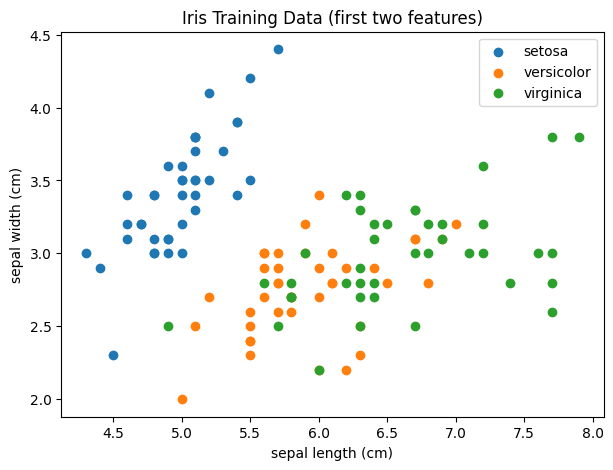

In [43]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

# Load data
iris = load_iris()
X, y = iris.data, iris.target
feature_names = iris.feature_names
target_names = iris.target_names

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Plot training data (first two features for 2D visualization)
plt.figure(figsize=(7,5))
for i, name in enumerate(target_names):
    plt.scatter(
        X_train[y_train == i, 0],
        X_train[y_train == i, 1],
        label=name
    )

plt.xlabel(feature_names[0])
plt.ylabel(feature_names[1])
plt.title("Iris Training Data (first two features)")
plt.legend()
plt.show()